# 02 — Baseline модели

Обучаем простые "из коробки" модели **без** дополнительного feature engineering —  
это наша точка отсчёта для оценки сложных экспериментов.

**Baseline модели:**
- Logistic Regression (линейный)
- K-Nearest Neighbors
- Decision Tree (без настройки)

**Метрика:** Weighted F1-score

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

from src.preprocessing import scale_features, NUMERIC_COLS, TARGET_COL
from src.modeling import evaluate_model, get_X_y, cross_validate_model, save_model, build_experiment_table

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Libraries loaded')

Libraries loaded


In [2]:
# Загружаем НЕмасштабированные данные (без FE)
train = pd.read_csv('../data/processed/train.csv')
val   = pd.read_csv('../data/processed/val.csv')
test  = pd.read_csv('../data/processed/test.csv')

# Масштабируем числовые признаки
train_scaled, val_scaled, test_scaled, scaler = scale_features(train, val, test)
joblib.dump(scaler, '../models/scaler_baseline.pkl')  # сохраним scaler

X_train, y_train = get_X_y(train_scaled)
X_val, y_val     = get_X_y(val_scaled)
X_test, y_test   = get_X_y(test_scaled)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (105000, 34), Val: (22500, 34), Test: (22500, 34)


## 0. Dummy Classifier (нижняя граница)
Предсказывает всегда самый частый класс — F1 этой модели нельзя быть хуже.

In [3]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_metrics = evaluate_model(dummy, X_val, y_val, 'val')


=== VAL ===
  accuracy: 0.3351
  weighted_f1: 0.1682
  macro_f1: 0.1673
  roc_auc_ovr: 0.5

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      7465
           1       0.34      1.00      0.50      7540
           2       0.00      0.00      0.00      7495

    accuracy                           0.34     22500
   macro avg       0.11      0.33      0.17     22500
weighted avg       0.11      0.34      0.17     22500



## 1. Logistic Regression

In [4]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs')
lr.fit(X_train, y_train)
lr_metrics = evaluate_model(lr, X_val, y_val, 'val')
save_model(lr, '../models/baseline_logreg.pkl')



=== VAL ===
  accuracy: 0.3342
  weighted_f1: 0.3325
  macro_f1: 0.3324
  roc_auc_ovr: 0.4976

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.28      0.30      7465
           1       0.34      0.40      0.36      7540
           2       0.33      0.32      0.33      7495

    accuracy                           0.33     22500
   macro avg       0.33      0.33      0.33     22500
weighted avg       0.33      0.33      0.33     22500

Model saved to ../models/baseline_logreg.pkl


In [5]:
# Cross-validation на train для оценки устойчивости
lr_cv = cross_validate_model(lr, X_train, y_train, cv=5)
print(f'Logistic Regression CV F1: {lr_cv["cv_f1_mean"]} ± {lr_cv["cv_f1_std"]}')

CV F1 (weighted): 0.3333 ± 0.0022
Logistic Regression CV F1: 0.3333 ± 0.0022


## 2. K-Nearest Neighbors

In [6]:
knn = KNeighborsClassifier(n_neighbors=11, metric='euclidean', n_jobs=-1)
knn.fit(X_train, y_train)
knn_metrics = evaluate_model(knn, X_val, y_val, 'val')
save_model(knn, '../models/baseline_knn.pkl')


=== VAL ===
  accuracy: 0.3287
  weighted_f1: 0.3255
  macro_f1: 0.3256
  roc_auc_ovr: 0.4965

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.40      0.36      7465
           1       0.33      0.33      0.33      7540
           2       0.33      0.25      0.28      7495

    accuracy                           0.33     22500
   macro avg       0.33      0.33      0.33     22500
weighted avg       0.33      0.33      0.33     22500

Model saved to ../models/baseline_knn.pkl


In [7]:
knn_cv = cross_validate_model(knn, X_train, y_train, cv=5)
print(f'KNN CV F1: {knn_cv["cv_f1_mean"]} ± {knn_cv["cv_f1_std"]}')

CV F1 (weighted): 0.3307 ± 0.0028
KNN CV F1: 0.3307 ± 0.0028


## 3. Decision Tree (без pruning)

In [8]:
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
dt_metrics = evaluate_model(dt, X_val, y_val, 'val')
save_model(dt, '../models/baseline_dt.pkl')


=== VAL ===
  accuracy: 0.3318
  weighted_f1: 0.3318
  macro_f1: 0.3318
  roc_auc_ovr: 0.4989

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.33      0.33      7465
           1       0.34      0.34      0.34      7540
           2       0.33      0.32      0.32      7495

    accuracy                           0.33     22500
   macro avg       0.33      0.33      0.33     22500
weighted avg       0.33      0.33      0.33     22500

Model saved to ../models/baseline_dt.pkl


In [9]:
dt_cv  = cross_validate_model(dt, X_train, y_train, cv=5)
print(f'Decision Tree CV F1: {dt_cv["cv_f1_mean"]} ± {dt_cv["cv_f1_std"]}')

CV F1 (weighted): 0.3336 ± 0.0012
Decision Tree CV F1: 0.3336 ± 0.0012


## Итоговое сравнение baseline моделей

In [10]:
results = [
    {'model_name': 'Dummy (most_frequent)', 'hypothesis': 'Нижняя граница', **dummy_metrics},
    {'model_name': 'Logistic Regression', 'hypothesis': 'Линейное разделение', 
     'cv_f1': f"{lr_cv['cv_f1_mean']} ± {lr_cv['cv_f1_std']}", **lr_metrics},
    {'model_name': 'KNN (k=11)', 'hypothesis': 'Похожие студенты', 
     'cv_f1': f"{knn_cv['cv_f1_mean']} ± {knn_cv['cv_f1_std']}", **knn_metrics},
    {'model_name': 'Decision Tree', 'hypothesis': 'Нелинейные правила', 
     'cv_f1': f"{dt_cv['cv_f1_mean']} ± {dt_cv['cv_f1_std']}", **dt_metrics},
]
table = build_experiment_table(results)
table.to_csv('../report/baseline_results.csv', index=False)
table

,model_name,hypothesis,split,accuracy,weighted_f1,macro_f1,roc_auc_ovr,cv_f1
1,Logistic Regression,Линейное разделение,val,0.3342,0.3325,0.3324,0.4976,0.3333 ± 0.0022
3,Decision Tree,Нелинейные правила,val,0.3318,0.3318,0.3318,0.4989,0.3336 ± 0.0012
2,KNN (k=11),Похожие студенты,val,0.3287,0.3255,0.3256,0.4965,0.3307 ± 0.0028
0,Dummy (most_frequent),Нижняя граница,val,0.3351,0.1682,0.1673,0.5000,NaN


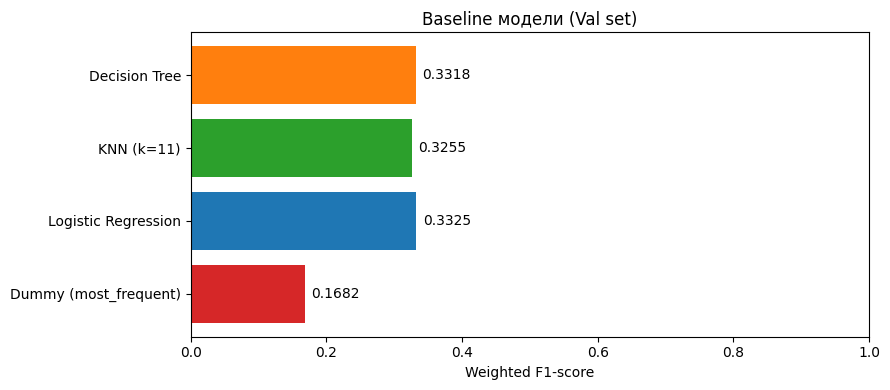

In [11]:
# График сравнения
fig, ax = plt.subplots(figsize=(9, 4))
models = [r['model_name'] for r in results]
f1_scores = [r.get('weighted_f1', 0) for r in results]
bars = ax.barh(models, f1_scores, color=['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e'])
ax.set_xlabel('Weighted F1-score')
ax.set_title('Baseline модели (Val set)')
ax.set_xlim(0, 1.0)
for bar, val in zip(bars, f1_scores):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')
plt.tight_layout()
plt.savefig('../report/images/baseline_comparison.png', dpi=150)
plt.show()

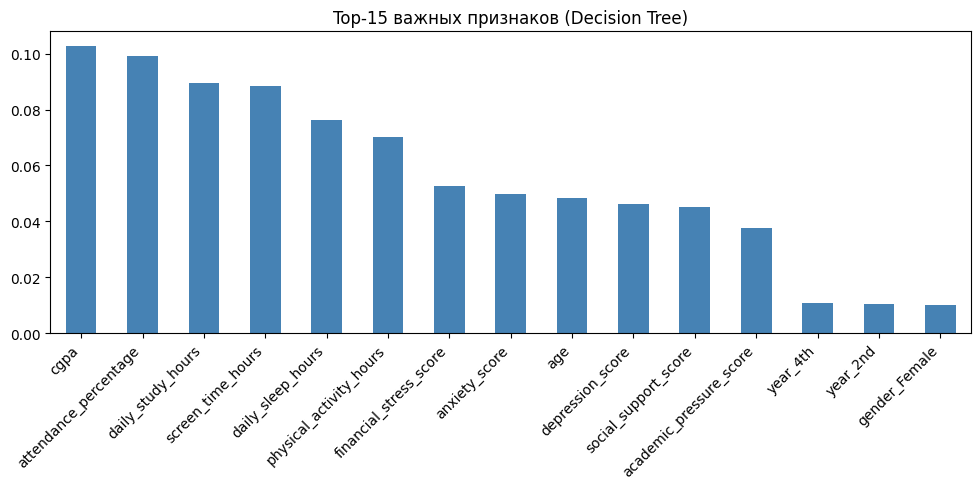

In [12]:
# Важность признаков Decision Tree
feat_imp = pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.head(15).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top-15 важных признаков (Decision Tree)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../report/images/dt_feature_importance.png', dpi=150)
plt.show()